In [1]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from shutil import copy2
from tqdm import tqdm

from pathlib import Path

import torch
import timm

from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\krbsv\miniconda3\envs\flora\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
data = pd.read_csv('observations-743067.csv')
data

,id,uuid,observed_on_string,observed_on,time_observed_at,time_zone,user_id,user_login,user_name,created_at,...,geoprivacy,taxon_geoprivacy,coordinates_obscured,positioning_method,positioning_device,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id
0,12520647,6795dac7-e95a-4c0f-b311-55ac2e01983c,Wed Jul 22 2015 15:30:24 GMT+0300 (GMT+3),2015-07-22,2015-07-22 13:30:24 +0100,Baghdad,659949,boulate,Bulat Savlaev,2018-05-16 19:58:20 +0100,...,NaN,NaN,False,NaN,NaN,Lilium kesselringianum,Lilium kesselringianum,NaN,Plantae,565750
1,16497988,76fd673e-e420-4b98-a601-218e06d240a7,2018-09-13 10:11:24 AM GMT+03:00,2018-09-13,2018-09-13 08:11:24 +0100,Baghdad,1183679,iron4ik,Андрей,2018-09-13 19:40:59 +0100,...,NaN,open,False,gps,gps,hawthorns,Crataegus,hawthorns,Plantae,51148
2,20235989,6fcaa71e-5491-421a-9934-a36c1c8b583d,2015/07/04 9:39 PM SST,2015-07-04,2015-07-04 09:39:00 +0100,Samoa,1467106,ivan_savinov,ivan_savinov,2019-02-09 21:26:45 +0100,...,NaN,NaN,False,NaN,NaN,Campanula collina,Campanula collina,NaN,Plantae,862161
3,20235990,bf5fd99e-4506-4bdd-862b-0df67d847b37,2015/07/04 9:47 PM SST,2015-07-04,2015-07-04 09:47:00 +0100,Samoa,1467106,ivan_savinov,ivan_savinov,2019-02-09 21:26:46 +0100,...,NaN,NaN,False,NaN,NaN,Verbascum pyramidatum,Verbascum pyramidatum,Caucasian Mullein,Plantae,371657
4,20235991,4473cb38-b6e6-4831-a7cd-4987786d0f05,2015/07/04 9:48 PM SST,2015-07-04,2015-07-04 09:48:00 +0100,Samoa,1467106,ivan_savinov,ivan_savinov,2019-02-09 21:26:46 +0100,...,NaN,NaN,False,NaN,NaN,musk thistle,Carduus nutans,musk thistle,Plantae,76007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11801,366308971,f32f401b-0c51-4040-8284-7326c11ff1ab,2026/05/27 12:22,2026-05-27,2026-05-27 10:22:00 +0100,St. Petersburg,3175852,krylenkosl,Krylenko VV,2026-05-29 13:06:57 +0100,...,NaN,NaN,False,NaN,NaN,Кислица Рожковая · Квасениця Рогата,Oxalis corniculata,Creeping Woodsorrel,Plantae,53168
11802,366308978,e30f7647-bdf1-4c07-9bd1-a7c522642ce0,2026/05/27 12:23,2026-05-27,2026-05-27 10:23:00 +0100,St. Petersburg,3175852,krylenkosl,Krylenko VV,2026-05-29 13:06:59 +0100,...,NaN,NaN,False,NaN,NaN,Аистник Обыкновенный · Грабельки Звичайні,Erodium cicutarium,Redstem Stork's-bill,Plantae,47687
11803,366308979,2f110147-1817-4a90-97e3-fb876a626154,2026/05/27 12:23,2026-05-27,2026-05-27 10:23:00 +0100,St. Petersburg,3175852,krylenkosl,Krylenko VV,2026-05-29 13:06:59 +0100,...,NaN,open,False,NaN,NaN,Ромашка Пахучая · Ромашка Пахуча,Matricaria discoidea,pineapple-weed,Plantae,52992
11804,367087575,59926407-2f0f-46d0-bd6c-90c1bda1301a,2026-05-28,2026-05-28,NaN,St. Petersburg,9370617,leshanna,NaN,2026-05-31 17:17:10 +0100,...,NaN,NaN,False,gps,gps,Первоцвет весенний,Primula veris,Cowslip,Plantae,55819


In [4]:
data['taxon_id'].value_counts().head(15)

taxon_id
129083    71
204380    67
906115    66
48596     62
128689    62
864581    53
546910    52
47124     48
53453     44
752467    43
163812    43
56023     43
131610    42
509258    42
564922    42
Name: count, dtype: int64

In [5]:
data['taxon_id'].value_counts().head(15).index

Index([129083, 204380, 906115,  48596, 128689, 864581, 546910,  47124,  53453,
       752467, 163812,  56023, 131610, 509258, 564922],
      dtype='int64', name='taxon_id')

In [6]:
for index in data['taxon_id'].value_counts().head(15).index:
    print(data.loc[data['taxon_id'] == index, 'scientific_name'].head(1))

286    Rhododendron luteum
Name: scientific_name, dtype: str
66    Phedimus spurius
Name: scientific_name, dtype: str
18    Betonica macrantha
Name: scientific_name, dtype: str
8    Campanula
Name: scientific_name, dtype: str
71    Salvia verticillata
Name: scientific_name, dtype: str
22    Pinus sylvestris hamata
Name: scientific_name, dtype: str
305    Rhododendron caucasicum
Name: scientific_name, dtype: str
202    Magnoliopsida
Name: scientific_name, dtype: str
375    Salix
Name: scientific_name, dtype: str
13    Bistorta carnea
Name: scientific_name, dtype: str
254    Hippophae rhamnoides
Name: scientific_name, dtype: str
400    Alchemilla
Name: scientific_name, dtype: str
9    Gymnadenia conopsea
Name: scientific_name, dtype: str
14    Veronica gentianoides
Name: scientific_name, dtype: str
116    Chamaenerion colchicum
Name: scientific_name, dtype: str


129083,204380,906115,48596,128689,864581,546910,47124,53453,752467,163812,56023,131610,509258,564922

In [7]:
df = pd.read_csv('observations_extended.csv')
df

,id,user_id,image_url,scientific_name,iconic_taxon_name,taxon_id
0,1578754,100898,https://inaturalist-open-data.s3.amazonaws.com/photos/1950847/medium.jpg,Sempervivum ingwersenii,Plantae,710078
1,6316472,487760,https://inaturalist-open-data.s3.amazonaws.com/photos/7954459/medium.jpg,Rhododendron caucasicum,Plantae,546910
2,6525233,443582,https://static.inaturalist.org/photos/8266408/medium.jpg,Carpinus betulus,Plantae,55801
3,6525236,443582,https://static.inaturalist.org/photos/8266411/medium.jpg,Potentilla indica,Plantae,243824
4,6578436,443582,https://static.inaturalist.org/photos/8346200/medium.jpg,Trifolium campestre,Plantae,57076
...,...,...,...,...,...,...
118696,367134735,3175852,https://inaturalist-open-data.s3.amazonaws.com/photos/670432905/medium.jpg,Plantago lanceolata,Plantae,53178
118697,367134743,3175852,https://inaturalist-open-data.s3.amazonaws.com/photos/670433002/medium.jpg,Medicago lupulina,Plantae,57056
118698,367134744,3175852,https://inaturalist-open-data.s3.amazonaws.com/photos/670433045/medium.jpg,Chelidonium majus,Plantae,55757
118699,367138747,3239633,https://inaturalist-open-data.s3.amazonaws.com/photos/670438133/medium.jpg,Cerinthe minor,Plantae,319307


In [8]:
top15_taxa = data['taxon_id'].value_counts().head(15).index
df_final = df[df['taxon_id'].isin(top15_taxa)]

In [9]:
df_final[["taxon_id", "scientific_name"]].drop_duplicates().sort_values("scientific_name")

,taxon_id,scientific_name
295,56023,Alchemilla
18,906115,Betonica macrantha
15,752467,Bistorta carnea
159,564922,Chamaenerion colchicum
12,131610,Gymnadenia conopsea
363,163812,Hippophae rhamnoides
161,204380,Phedimus spurius
496,864581,Pinus sylvestris hamata
1,546910,Rhododendron caucasicum
21,129083,Rhododendron luteum


In [10]:
df_final

,id,user_id,image_url,scientific_name,iconic_taxon_name,taxon_id
1,6316472,487760,https://inaturalist-open-data.s3.amazonaws.com/photos/7954459/medium.jpg,Rhododendron caucasicum,Plantae,546910
12,7294238,21240,https://inaturalist-open-data.s3.amazonaws.com/photos/9436808/medium.jpeg,Gymnadenia conopsea,Plantae,131610
14,7294258,21240,https://inaturalist-open-data.s3.amazonaws.com/photos/9436842/medium.jpeg,Veronica gentianoides,Plantae,509258
15,7294260,21240,https://inaturalist-open-data.s3.amazonaws.com/photos/9436845/medium.jpeg,Bistorta carnea,Plantae,752467
17,7294297,21240,https://inaturalist-open-data.s3.amazonaws.com/photos/9436895/medium.jpeg,Rhododendron caucasicum,Plantae,546910
...,...,...,...,...,...,...
118469,366291215,7435685,https://inaturalist-open-data.s3.amazonaws.com/photos/668836214/medium.jpg,Veronica gentianoides,Plantae,509258
118524,366387874,3239633,https://inaturalist-open-data.s3.amazonaws.com/photos/669001237/medium.jpg,Rhododendron luteum,Plantae,129083
118537,366422964,4169506,https://inaturalist-open-data.s3.amazonaws.com/photos/669077945/medium.jpg,Rhododendron luteum,Plantae,129083
118553,366600361,7435685,https://inaturalist-open-data.s3.amazonaws.com/photos/669419252/medium.jpg,Veronica gentianoides,Plantae,509258


In [11]:
df_final['scientific_name'].value_counts()

scientific_name
Phedimus spurius           945
Betonica macrantha         883
Veronica gentianoides      844
Rhododendron caucasicum    797
Rhododendron luteum        611
Salvia verticillata        602
Gymnadenia conopsea        581
Bistorta carnea            578
Pinus sylvestris hamata    482
Chamaenerion colchicum     462
Hippophae rhamnoides       220
Alchemilla                  50
Name: count, dtype: int64

In [11]:
# df_final.to_csv('plants.csv')

In [12]:
SOURCE_DIR = Path("data/images")

OUTPUT_DIR = Path("data/split")

TRAIN_DIR = OUTPUT_DIR / "train"
VAL_DIR = OUTPUT_DIR / "val"
TEST_DIR = OUTPUT_DIR / "test"

In [13]:
# for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
#     directory.mkdir(parents=True, exist_ok=True)

# for class_dir in SOURCE_DIR.iterdir():

#     if not class_dir.is_dir():
#         continue

#     images = list(class_dir.glob("*"))

#     train_files, temp_files = train_test_split(
#         images,
#         test_size=0.2,
#         random_state=42
#     )

#     val_files, test_files = train_test_split(
#         temp_files,
#         test_size=0.5,
#         random_state=42
#     )

#     for split_name, files in [
#         ("train", train_files),
#         ("val", val_files),
#         ("test", test_files),
#     ]:

#         target_class_dir = OUTPUT_DIR / split_name / class_dir.name
#         target_class_dir.mkdir(parents=True, exist_ok=True)

#         for file in tqdm(
#             files,
#             desc=f"{split_name}: {class_dir.name}"
#         ):
#             copy2(
#                 file,
#                 target_class_dir / file.name
#             )

# print("\nDataset split completed.")

In [14]:
# # ==========================
# # CONFIG
# # ==========================

# DATA_DIR = "data/split"

# BATCH_SIZE = 64
# NUM_EPOCHS = 30
# LEARNING_RATE = 1e-4

# PATIENCE = 5

# MODEL_PATH = "best_model.pth"

In [15]:
# # ==========================
# # DEVICE
# # ==========================

# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )

# print("Device:", device)

Device: cuda


In [16]:
# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.device_count())
# print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.11.0+cu128
True
1
NVIDIA GeForce RTX 4060 Ti


In [17]:
# # ==========================
# # TRANSFORMS
# # ==========================

# train_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15),
#     transforms.ColorJitter(
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.2
#     ),
#     transforms.ToTensor(),
# ])

# val_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])

In [18]:
# ==========================
# DATASETS
# ==========================

train_dataset = datasets.ImageFolder(
    Path(DATA_DIR) / "train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    Path(DATA_DIR) / "val",
    transform=val_transforms
)

print("Classes:", train_dataset.classes)

num_classes = len(train_dataset.classes)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

Classes: ['Alchemilla', 'Betonica macrantha', 'Bistorta carnea', 'Chamaenerion colchicum', 'Gymnadenia conopsea', 'Hippophae rhamnoides', 'Phedimus spurius', 'Pinus sylvestris hamata', 'Rhododendron caucasicum', 'Rhododendron luteum', 'Salvia verticillata', 'Veronica gentianoides']


In [19]:
# # ==========================
# # MODEL
# # ==========================

# model = timm.create_model(
#     "efficientnet_b0",
#     pretrained=True,
#     num_classes=num_classes
# )

# model.to(device)

# # ==========================
# # LOSS / OPTIMIZER
# # ==========================

# criterion = nn.CrossEntropyLoss()

# optimizer = AdamW(
#     model.parameters(),
#     lr=LEARNING_RATE
# )

# # ==========================
# # MIXED PRECISION
# # ==========================

# scaler = torch.cuda.amp.GradScaler()

# # ==========================
# # EARLY STOPPING
# # ==========================

# best_val_acc = 0.0
# patience_counter = 0


C:\Users\krbsv\miniconda3\envs\flora\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\krbsv\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\krbsv\AppData\Local\Temp\ipykernel_11752\2815160317.py:28: FutureWarning: `torch.cuda.amp.Grad

In [20]:
# # ==========================
# # TRAIN LOOP
# # ==========================

# for epoch in range(NUM_EPOCHS):

#     print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

#     # ----------------------
#     # TRAIN
#     # ----------------------

#     model.train()

#     train_loss = 0.0
#     train_correct = 0
#     train_total = 0

#     for images, labels in tqdm(train_loader):

#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         with torch.cuda.amp.autocast():

#             outputs = model(images)

#             loss = criterion(
#                 outputs,
#                 labels
#             )

#         scaler.scale(loss).backward()

#         scaler.step(optimizer)

#         scaler.update()

#         train_loss += loss.item()

#         _, preds = outputs.max(1)

#         train_correct += (
#             preds == labels
#         ).sum().item()

#         train_total += labels.size(0)

#     train_acc = train_correct / train_total

#     # ----------------------
#     # VALIDATION
#     # ----------------------

#     model.eval()

#     val_loss = 0.0
#     val_correct = 0
#     val_total = 0

#     with torch.no_grad():

#         for images, labels in val_loader:

#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)

#             loss = criterion(
#                 outputs,
#                 labels
#             )

#             val_loss += loss.item()

#             _, preds = outputs.max(1)

#             val_correct += (
#                 preds == labels
#             ).sum().item()

#             val_total += labels.size(0)

#     val_acc = val_correct / val_total

#     print(
#         f"Train Loss: {train_loss:.4f} | "
#         f"Train Acc: {train_acc:.4f}"
#     )

#     print(
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Acc: {val_acc:.4f}"
#     )

#     # ----------------------
#     # SAVE BEST MODEL
#     # ----------------------

#     if val_acc > best_val_acc:

#         best_val_acc = val_acc

#         torch.save(
#             {
#                 "model_state_dict": model.state_dict(),
#                 "class_names": train_dataset.classes,
#             },
#             MODEL_PATH
#         )

#         print(
#             f"Best model saved. "
#             f"Val Acc={val_acc:.4f}"
#         )

#         patience_counter = 0

#     else:

#         patience_counter += 1

#         print(
#             f"No improvement. "
#             f"Patience {patience_counter}/{PATIENCE}"
#         )

#         if patience_counter >= PATIENCE:

#             print("Early stopping triggered.")
#             break

# print("\nTraining finished.")
# print(f"Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/30


  0%|                                                                                           | 0/89 [00:00<?, ?it/s]C:\Users\krbsv\AppData\Local\Temp\ipykernel_11752\3752765444.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████████████████████████████████████████████████████████████████████████████| 89/89 [00:39<00:00,  2.26it/s]


Train Loss: 168.3899 | Train Acc: 0.4643
Val Loss: 10.6730 | Val Acc: 0.6960
Best model saved. Val Acc=0.6960

Epoch 2/30


100%|██████████████████████████████████████████████████████████████████████████████████| 89/89 [00:20<00:00,  4.41it/s]


Train Loss: 58.6342 | Train Acc: 0.7898
Val Loss: 7.0085 | Val Acc: 0.7940
Best model saved. Val Acc=0.7940

Epoch 3/30


...

Train Loss: 1.8952 | Train Acc: 0.9950
Val Loss: 4.0381 | Val Acc: 0.9062
No improvement. Patience 3/5

Epoch 19/30


100%|██████████████████████████████████████████████████████████████████████████████████| 89/89 [00:20<00:00,  4.43it/s]


Train Loss: 2.2970 | Train Acc: 0.9956
Val Loss: 4.2347 | Val Acc: 0.9006
No improvement. Patience 4/5

Epoch 20/30


100%|██████████████████████████████████████████████████████████████████████████████████| 89/89 [00:20<00:00,  4.41it/s]


Train Loss: 1.4129 | Train Acc: 0.9959
Val Loss: 4.1803 | Val Acc: 0.8977
No improvement. Patience 5/5
Early stopping triggered.

Training finished.
Best validation accuracy: 0.9119


In [13]:
DEVICE = torch.device("cuda")

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_dataset = datasets.ImageFolder(
    Path("data/split/test"),
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

checkpoint = torch.load(
    "best_model.pth",
    map_location=DEVICE
)

class_names = checkpoint["class_names"]

model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=len(class_names)
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(
    y_true,
    y_pred
)

print(f"\nTest Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Test Accuracy: 0.9242
                         precision    recall  f1-score   support

             Alchemilla       1.00      0.20      0.33         5
     Betonica macrantha       0.92      0.96      0.94        89
        Bistorta carnea       0.93      0.93      0.93        58
 Chamaenerion colchicum       0.90      0.96      0.93        47
    Gymnadenia conopsea       0.97      0.95      0.96        59
   Hippophae rhamnoides       0.89      0.77      0.83        22
       Phedimus spurius       0.96      0.97      0.96        95
Pinus sylvestris hamata       0.91      0.82      0.86        49
Rhododendron caucasicum       0.91      0.96      0.93        80
    Rhododendron luteum       0.89      0.92      0.90        62
    Salvia verticillata       0.93      0.90      0.92        61
  Veronica gentianoides       0.92      0.93      0.92        85

               accuracy                           0.92       712
              macro avg       0.93      0.86      0.87       712


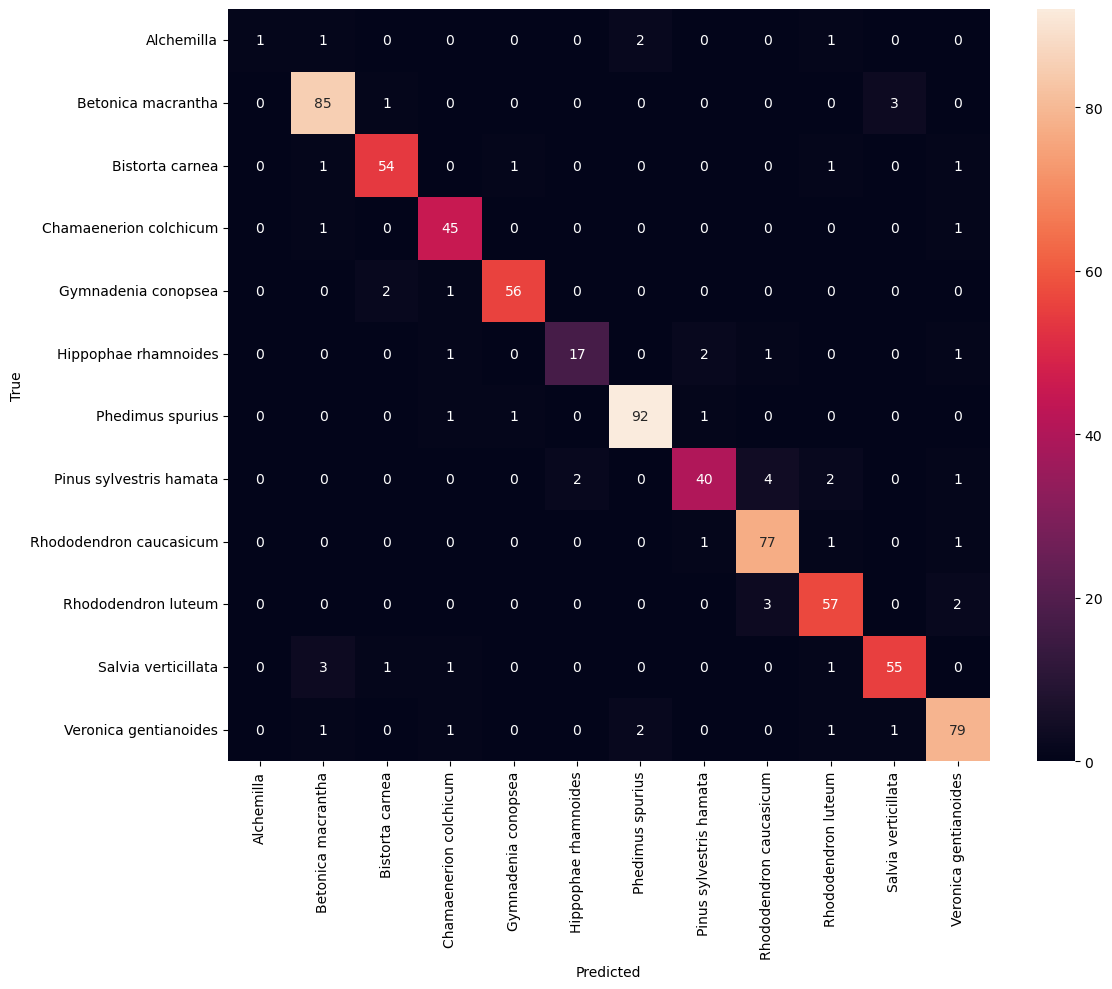

In [16]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()